In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dengue/dataset.xlsx
/kaggle/input/city-corporation/city_corporation_actions.csv


In [3]:
#Layer 1: Dengue Risk Prediction
--------------------------------
#This module preprocesses climate and dengue data and trains
#machine learning models to predict dengue risk levels.
#STEP 0: Import Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


In [4]:
#Step 2: Load Dataset
df = pd.read_excel("/kaggle/input/dengue/dataset.xlsx")


df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Division     576 non-null    object 
 1   Year         576 non-null    int64  
 2   Month        576 non-null    object 
 3   Pollution    576 non-null    object 
 4   Density      576 non-null    object 
 5   Infected     576 non-null    int64  
 6   Death        576 non-null    int64  
 7   temperature  576 non-null    object 
 8   Humidity     576 non-null    float64
 9   Pressure     576 non-null    object 
 10  Class        576 non-null    object 
dtypes: float64(1), int64(3), object(7)
memory usage: 49.6+ KB


In [5]:
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

df['Month'] = df['Month'].map(month_map)

In [6]:
#STEP 3: Fix merged / messy columns 

#If Year-Month is merged:

df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)

In [7]:
df[['Year', 'Month']].head()

,Year,Month
0,2020,1
1,2020,2
2,2020,3
3,2020,4
4,2020,5


In [8]:
# STEP 2: Clean temperature column
df['temperature'] = (
    df['temperature']
    .astype(str)
    .str.replace('°C', '', regex=False)
    .str.strip()
    .astype(float)
)

In [9]:
# STEP 3: Clean pressure column

df['Pressure '] = (
    df['Pressure ']
    .astype(str)
    .str.extract(r'([\d\.]+)')   # extract only numbers
    .astype(float)
)

In [10]:
# Density (ordinal)
density_map = {
    'Very Low': 1,
    'Low': 2,
    'Medium': 3,
    'High': 4,
    'Very High': 5
}
df['Density'] = df['Density'].map(density_map)

In [11]:
# STEP 5: Encode Categorical Environmental Variables
#Pollution (ordinal)
pollution_map = {
    'Very Low': 0,
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Very High': 4
}
df['Pollution'] = df['Pollution'].replace(pollution_map)

In [12]:
# STEP 6: Handle Missing Values
num_cols = [
    'Pollution', 'Density',
    'temperature', 'Humidity', 'Pressure '
]

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [13]:
risk_map = {
    "Very Low": 0,
    "Low": 1,
    "Medium": 2,
    "High": 3
}

df['Target'] = df['Class'].map(risk_map).astype(int)

print(df['Target'].value_counts().sort_index())

Target
0    130
1    149
2    129
3    168
Name: count, dtype: int64


In [14]:
# STEP 7: Encode Division (KEEP IT)
df = pd.get_dummies(df, columns=['Division'], drop_first=True)

In [15]:
features = [
    'Year', 'Month', 'Pollution', 'Density',
    'temperature', 'Humidity', 'Pressure '
]

X = df[features]
y = df['Target']

In [16]:
#STEP 9: Train–Test Split (Stratified)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [17]:
# STEP 10: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [221]:
X.isna().sum().sort_values(ascending=False).head(10)



temperature            0
Humidity               0
Pressure               0
Pollution              0
Density                0
Division_Chattogram    0
Division_Dhaka         0
Division_Khulna        0
Division_Mymensingh    0
Division_Rajshahi      0
dtype: int64

In [18]:
# Logistic Regression
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.4652777777777778
              precision    recall  f1-score   support

           0       0.57      0.64      0.60        33
           1       0.37      0.38      0.37        37
           2       0.29      0.25      0.27        32
           3       0.59      0.57      0.58        42

    accuracy                           0.47       144
   macro avg       0.45      0.46      0.45       144
weighted avg       0.46      0.47      0.46       144



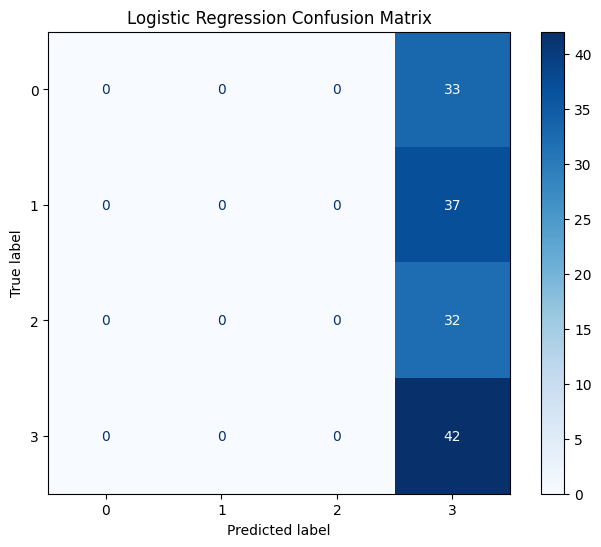

In [19]:
# Create the display
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test, cmap='Blues', ax=ax)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [20]:
#Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.6805555555555556
              precision    recall  f1-score   support

           0       0.64      0.70      0.67        33
           1       0.58      0.51      0.54        37
           2       0.57      0.66      0.61        32
           3       0.92      0.83      0.88        42

    accuracy                           0.68       144
   macro avg       0.68      0.68      0.67       144
weighted avg       0.69      0.68      0.68       144



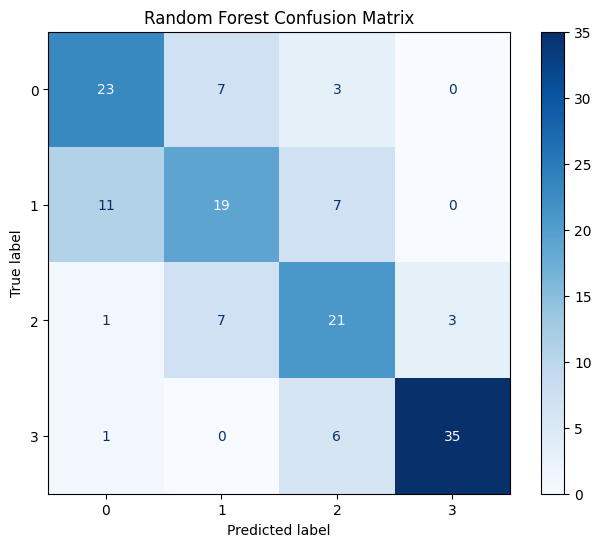

In [21]:
# Create the display
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap='Blues', ax=ax)
plt.title('Random Forest Confusion Matrix')
plt.show()

In [22]:
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.6458333333333334
              precision    recall  f1-score   support

           0       0.62      0.61      0.62        33
           1       0.46      0.46      0.46        37
           2       0.54      0.62      0.58        32
           3       0.95      0.86      0.90        42

    accuracy                           0.65       144
   macro avg       0.64      0.64      0.64       144
weighted avg       0.66      0.65      0.65       144



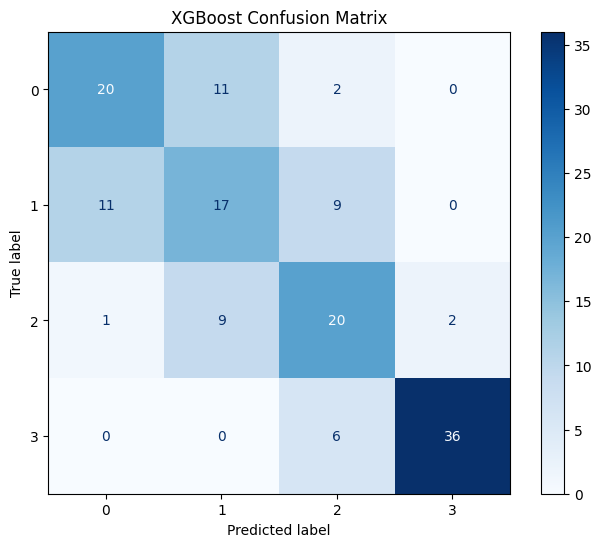

In [23]:
# Create the display
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test, cmap='Blues', ax=ax)
plt.title('XGBoost Confusion Matrix')
plt.show()

In [24]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.465278
1,Random Forest,0.680556
2,XGBoost,0.645833


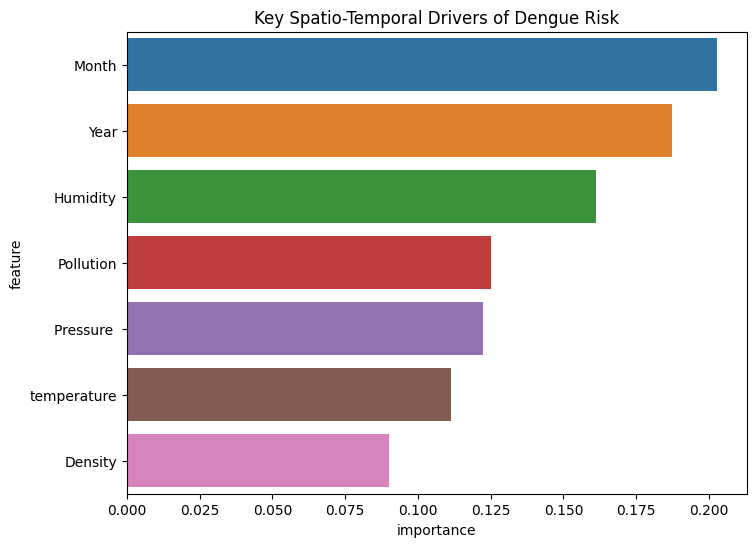

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp.head(10), x='importance', y='feature')
plt.title("Key Spatio-Temporal Drivers of Dengue Risk")
plt.show()

In [26]:
# # Use best model (XGBoost or Logistic Regression – both gave 0.80)
layer1_output = df.copy()

layer1_output['Predicted_Risk'] = rf.predict(X)

layer1_output.to_csv("layer1_predictions.csv", index=False)


In [27]:
# Layer 2
#STEP 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
import pandas as pd

# Layer 1 output (save this earlier!)
risk_df = pd.read_csv("layer1_predictions.csv")

# City Corporation actions dataset

action_df = pd.read_csv(
    "/kaggle/input/city-corporation/city_corporation_actions.csv",
    encoding="latin-1"
)

action_df.head()

# Clean column names
risk_df.columns = risk_df.columns.str.strip()
action_df.columns = action_df.columns.str.strip()



In [238]:
risk_df.head()

,Year,Month,Pollution,Density,Infected,Death,temperature,Humidity,Pressure,Class,Outbreak,Division_Chattogram,Division_Dhaka,Division_Khulna,Division_Mymensingh,Division_Rajshahi,Division_Rangpur,Division_Sylhet,Predicted_Risk
0,2020,1,3,4,88,0,19.0,0.80,1017.0,Medium,0,False,True,False,False,False,False,False,0
1,2020,2,3,4,17,0,23.0,0.63,1014.0,Low,0,False,True,False,False,False,False,False,0
2,2020,3,3,4,21,0,27.0,0.55,1011.0,Low,0,False,True,False,False,False,False,False,0
3,2020,4,3,4,20,0,28.0,0.70,1009.0,Low,0,False,True,False,False,False,False,False,0
4,2020,5,3,4,10,0,29.0,0.80,1005.0,Low,0,False,True,False,False,False,False,False,0


In [30]:
#STEP 2: Filter Dhaka only (City Corporations)
dhaka_risk = risk_df[
    (risk_df['Division_Dhaka'] == True)
].copy()

dhaka_risk = dhaka_risk[['Year', 'Month', 'Predicted_Risk']]

In [31]:
#STEP 3: Aggregate monthly dengue risk
monthly_risk = (
    dhaka_risk
    .groupby(['Year', 'Month'], as_index=False)
    .agg({'Predicted_Risk': 'mean'})
)

monthly_risk.head()

,Year,Month,Predicted_Risk
0,2020,1,2.0
1,2020,2,1.0
2,2020,3,1.0
3,2020,4,1.0
4,2020,5,1.0


In [32]:
#STEP 4: Convert actions → Action Intensity Score
action_score_map = {
    'cleanliness': 1,
    'larvicide': 2,
    'fogging': 2,
    'spraying': 2,
    'monitoring': 1,
    'awareness': 1,
    'eradication': 3,
    'drive': 3
}

In [33]:
def compute_action_score(action):
    score = 0
    for k, v in action_score_map.items():
        if k.lower() in action.lower():
            score += v
    return score

action_df['Action_Score'] = action_df['Action-Type'].apply(compute_action_score)

In [34]:
#STEP 5: Aggregate actions yearly (since news is yearly)
yearly_actions = (
    action_df
    .groupby(['Year', 'Corporation'], as_index=False)
    .agg({'Action_Score': 'sum'})
)

yearly_actions.head()

,Year,Corporation,Action_Score
0,2019,DNCC & DSCC,0
1,2020,DNCC,2
2,2021,DSCC,4
3,2022,DNCC,4
4,2023,DSCC,3


In [35]:
#STEP 6: Convert monthly risk → yearly risk
yearly_risk = (
    monthly_risk
    .groupby('Year', as_index=False)
    .agg({'Predicted_Risk': 'mean'})
)

yearly_risk.head()

,Year,Predicted_Risk
0,2020,1.583333
1,2021,2.166667
2,2022,2.333333
3,2023,2.833333
4,2024,2.750000


In [36]:
#STEP 7: Merge Risk with Corporation Actions
layer2_df = pd.merge(
    yearly_risk,
    yearly_actions,
    on='Year',
    how='left'
)

layer2_df.fillna(0, inplace=True)
layer2_df

,Year,Predicted_Risk,Corporation,Action_Score
0,2020,1.583333,DNCC,2
1,2021,2.166667,DSCC,4
2,2022,2.333333,DNCC,4
3,2023,2.833333,DSCC,3
4,2024,2.750000,DNCC,3
5,2024,2.750000,DSCC,3
6,2025,2.833333,DNCC,6
7,2025,2.833333,DSCC,3


In [37]:
#STEP 8: Compute Response Adequacy Score
layer2_df['Response_Adequacy'] = (
    layer2_df['Action_Score'] /
    (layer2_df['Predicted_Risk']+ 0.01)
)

In [38]:
# STEP 9: Categorize governance effectiveness
def governance_label(x):
    if x>2:
        return 'Proactive'
    elif x>1.5:
        return 'Moderate'
    else:
        return 'Reactive'

layer2_df['Governance_Response'] = layer2_df['Response_Adequacy'].apply(governance_label)

layer2_df

,Year,Predicted_Risk,Corporation,Action_Score,Response_Adequacy,Governance_Response
0,2020,1.583333,DNCC,2,1.255230,Reactive
1,2021,2.166667,DSCC,4,1.837672,Moderate
2,2022,2.333333,DNCC,4,1.706970,Moderate
3,2023,2.833333,DSCC,3,1.055100,Reactive
4,2024,2.750000,DNCC,3,1.086957,Reactive
5,2024,2.750000,DSCC,3,1.086957,Reactive
6,2025,2.833333,DNCC,6,2.110199,Proactive
7,2025,2.833333,DSCC,3,1.055100,Reactive


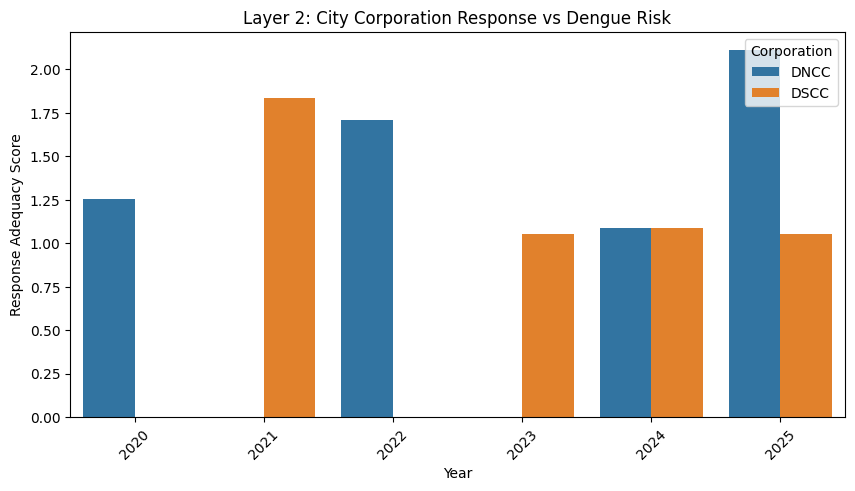

In [39]:
# STEP 10: Visualization (MANDATORY)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(
    data=layer2_df,
    x='Year',
    y='Response_Adequacy',
    hue='Corporation'
)
plt.title("Layer 2: City Corporation Response vs Dengue Risk")
plt.ylabel("Response Adequacy Score")
plt.xticks(rotation=45)
plt.show()